In [1]:
# Functions and dependencies
import time
import numpy as np
from icing_true import ICINGTrue
from icing_model import ICINGModel
from particle_filter import BootstrapParticleFilter
from ext_kalman_filter import ExtendedKalmanFilter
from utils import gen_uex_func, gen_PN_func, gen_D_func, gen_SI_func
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
rng = np.random.default_rng(seed=42)

In [2]:
# Simulation parameters
sim_hours = 60
dt = 1.0
t = np.arange(0, sim_hours*60+1, dt) #0 to 60 hours with minute-level resolution
y0 = [5.0, 15.0, 15.0, 0.0, 0.0] #Initial conditions: G, I, Q, P1, P2
D_const = 0
SI_const = 2e-4
uex_func = gen_uex_func()
PN_func = gen_PN_func()
D_func = gen_D_func(D_const)
SI_func = gen_SI_func(SI_const)
input_functions = {"D": D_func, "PN": PN_func, "Uex": uex_func}

In [3]:
# Simulation of true dynamics
gt_model = ICINGTrue()
G_true,_,_,_,_ = gt_model.simulate(y0, t[0], t[-1], t, uex_func, PN_func, D_func, SI_func)     

In [4]:
# Model Parameters
Ts_meas = 120 # Period in minutes of measurement sampling
t_meas = np.arange(0, sim_hours*60+1, Ts_meas) #0 to 60 hours with minute-level resolution
sample_indices = [np.argmin(np.abs(t - st)) for st in t_meas]
initial_state = np.append(y0[:3], [gt_model.params['k1']*np.exp(-y0[2]*gt_model.params['k2']/gt_model.params["k3"]), 2e-4])
initial_state = np.expand_dims(initial_state, axis=1)
process_noises = 1e-4/(Ts_meas)*np.ones((len(initial_state),))
process_noises[-1] = (1e-6)**2/(Ts_meas)
measurement_noise_std = 0.25
num_states = len(initial_state)

In [ ]:
# Run experiment
num_sim = 20
delta_initial_state = rng.uniform(-0.1,0.1, size=num_sim) # Initial state will deviate from -10% to 10%
delta_measurement_noise = rng.normal(0, measurement_noise_std, size=(num_sim,len(sample_indices))) # Measurement for all measured samples in each simulation
n_particles = np.arange(250,1250,250) # PF filters with 250, 500, 750, and 1000 particles
num_filters = len(n_particles) + 1 # 1 EKF filter and the number of variations of PF with the assigned number of particles
time_train = np.zeros(shape=(num_filters, num_sim))
mse_est = np.zeros_like(time_train)

for i in range(num_sim):
    print(f"Simulation {i+1} / {num_sim}")
    model = ICINGModel(params=None,dt=dt, initial_state=initial_state+delta_initial_state[i]*initial_state, process_noise_vars=process_noises, measurement_noise_var=measurement_noise_std**2, u_funcs=input_functions)
    G_meas = G_true[sample_indices] + delta_measurement_noise[i,:]

    for j in range(num_filters):
        if j != 0: # PF
            PF_filter = BootstrapParticleFilter(num_particles=n_particles[j-1], num_states=num_states, model=model, Ts_meas=Ts_meas)
            sim = PF_filter.simulate(t, t_meas, G_meas, PF_filter)
            timeStart = time.time()
            _, _, _, _, G_est, _, _, _, _,_ = sim.run()
            timeEnd = time.time()
            time_train[j,i] = timeEnd-timeStart
            mse_est[j,i] = mean_squared_error(G_true,G_est)
        else: # EKF 
            EKF_filter = ExtendedKalmanFilter(num_states=num_states, model=model, Ts_meas=Ts_meas)
            sim = EKF_filter.simulate(t, t_meas, G_meas, EKF_filter)
            timeStart = time.time()
            _, _, G_est, _, _, _, _,_ = sim.run()
            timeEnd = time.time()
            time_train[j,i] = timeEnd-timeStart
            mse_est[j,i] = mean_squared_error(G_true,G_est)

print("Done")

Simulation 1 / 20
Simulation 2 / 20
Simulation 3 / 20
Simulation 4 / 20
Simulation 5 / 20
Simulation 6 / 20
Simulation 7 / 20
Simulation 8 / 20
Simulation 9 / 20
Simulation 10 / 20
Simulation 11 / 20
Simulation 12 / 20
Simulation 13 / 20
Simulation 14 / 20
Simulation 15 / 20
Simulation 16 / 20
Simulation 17 / 20
Simulation 18 / 20
Simulation 19 / 20
Simulation 20 / 20
Done


In [6]:
np.save('delta_initial_arr', delta_initial_state)
np.save('delta_meas_noise', delta_measurement_noise)
np.save("time_arr", time_train)
np.save("mse_arr", mse_est)

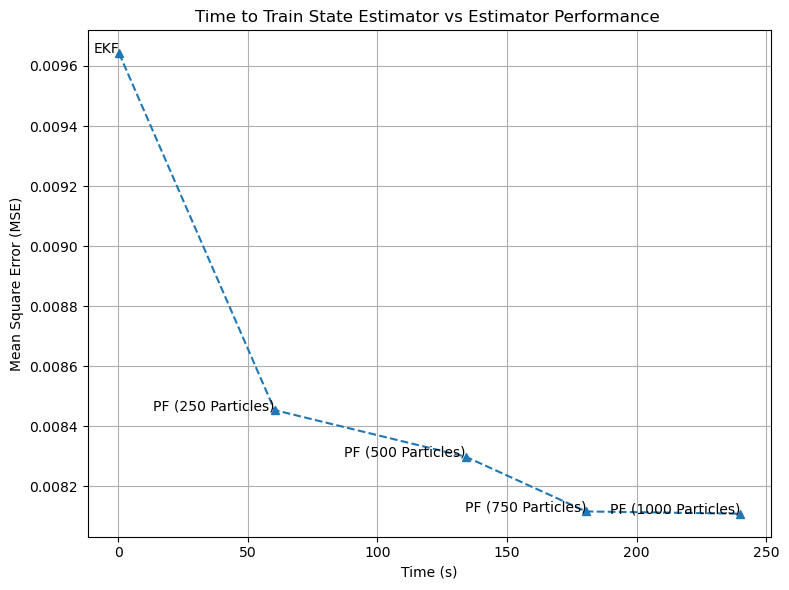

In [18]:
avg_mse_est = np.average(mse_est, axis=1)
avg_time_train = np.average(time_train, axis=1)
labels = ['EKF', 'PF (250 Particles)', 'PF (500 Particles)', 'PF (750 Particles)', 'PF (1000 Particles)']

fig, ax = plt.subplots(figsize=(8,6))
ax.plot(avg_time_train, avg_mse_est, linestyle='--', marker='^')
for x,y,label in zip(avg_time_train, avg_mse_est, labels):
    ax.annotate(label, (x,y), ha='right')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Mean Square Error (MSE)')
ax.set_title('Time to Train State Estimator vs Estimator Performance ')
ax.grid()
fig.tight_layout()